In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv(
    "Amazon_Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [9]:
df.shape

(21214, 9)

In [10]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       21214 non-null  str  
 1   Profile Link        21163 non-null  str  
 2   Country             21054 non-null  str  
 3   Review Count        21055 non-null  str  
 4   Review Date         21055 non-null  str  
 5   Rating              21055 non-null  str  
 6   Review Title        21055 non-null  str  
 7   Review Text         21055 non-null  str  
 8   Date of Experience  20947 non-null  str  
dtypes: str(9)
memory usage: 13.7 MB


In [12]:
df.isnull().sum()

Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [13]:
df.dropna(inplace=True)

df.isnull().sum()

Reviewer Name         0
Profile Link          0
Country               0
Review Count          0
Review Date           0
Rating                0
Review Title          0
Review Text           0
Date of Experience    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(20946, 9)

In [17]:
df["Rating"].unique()

<ArrowStringArray>
['Rated 1 out of 5 stars', 'Rated 5 out of 5 stars', 'Rated 2 out of 5 stars',
 'Rated 4 out of 5 stars', 'Rated 3 out of 5 stars']
Length: 5, dtype: str

In [18]:
df["Rating_Num"] = df["Rating"].str.extract(r'(\d)').astype(int)

df[["Rating","Rating_Num"]].head()

,Rating,Rating_Num
0,Rated 1 out of 5 stars,1
1,Rated 1 out of 5 stars,1
2,Rated 1 out of 5 stars,1
3,Rated 1 out of 5 stars,1
4,Rated 1 out of 5 stars,1


In [19]:
df["Rating_Num"].value_counts().sort_index()

Rating_Num
1    13120
2     1227
3      874
4     1278
5     4447
Name: count, dtype: int64

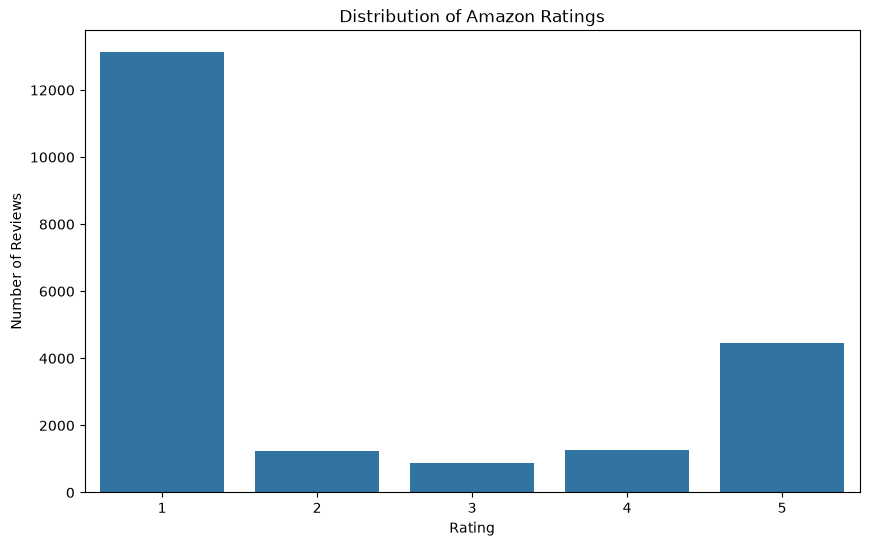

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Rating_Num",
    data=df,
    order=[1,2,3,4,5]
)

plt.title("Distribution of Amazon Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.savefig("rating_distribution.png")

plt.show()

In [21]:
df["Country"].value_counts().head(10)

Country
US    9260
GB    7238
CA     706
IN     628
IE     241
DK     236
NL     212
AU     184
DE     181
IT     147
Name: count, dtype: int64

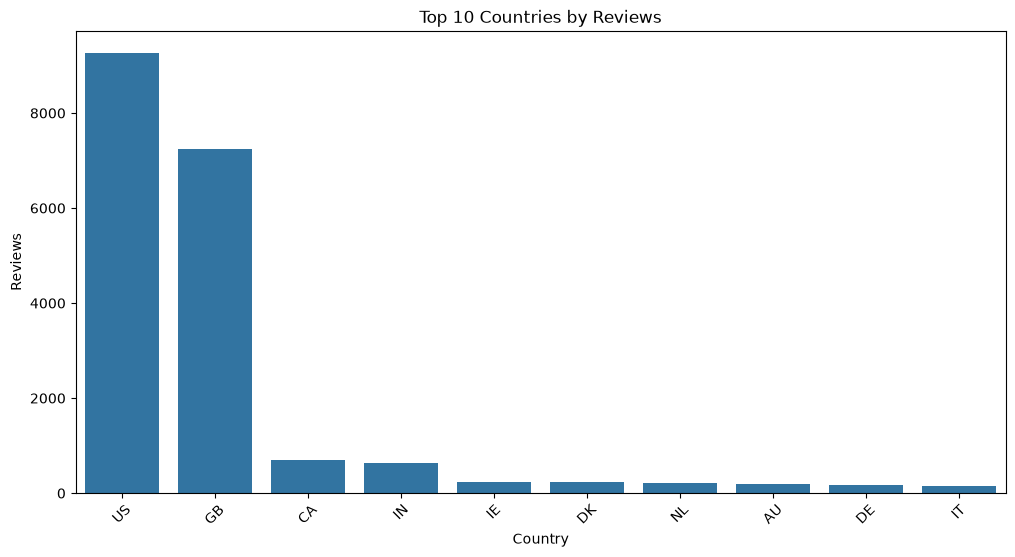

In [22]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Countries by Reviews")
plt.xlabel("Country")
plt.ylabel("Reviews")

plt.xticks(rotation=45)

plt.savefig("country_distribution.png")

plt.show()

In [23]:
df["Review_Length"] = df["Review Text"].astype(str).apply(len)

df["Review_Length"].describe()

count    20946.000000
mean       462.690251
std        517.256352
min         10.000000
25%        148.000000
50%        317.000000
75%        585.750000
max       9951.000000
Name: Review_Length, dtype: float64

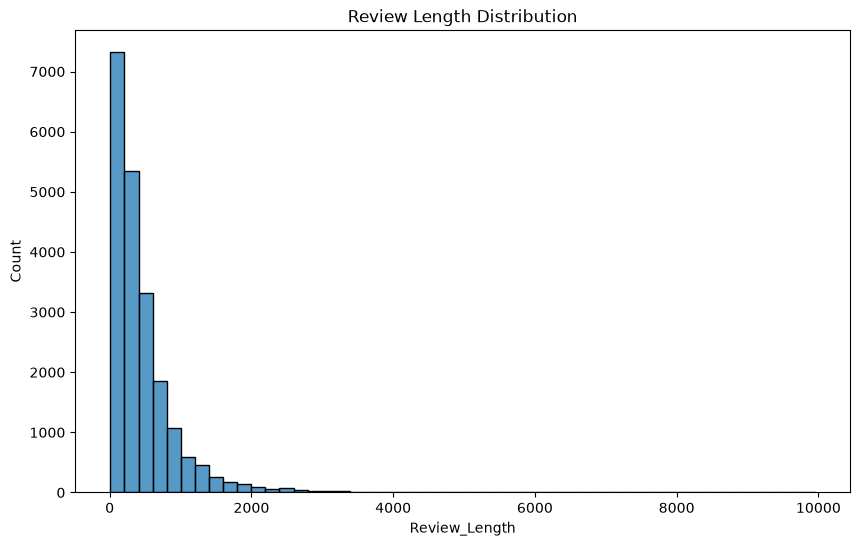

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Review_Length"],
    bins=50
)

plt.title("Review Length Distribution")

plt.savefig("review_length_distribution.png")

plt.show()

In [25]:
analyzer = SentimentIntensityAnalyzer()

In [26]:
def get_sentiment(text):

    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [27]:
df["Sentiment"] = df["Review Text"].apply(get_sentiment)

In [28]:
df["Sentiment"].value_counts()

Sentiment
Positive    10071
Negative     9408
Neutral      1467
Name: count, dtype: int64

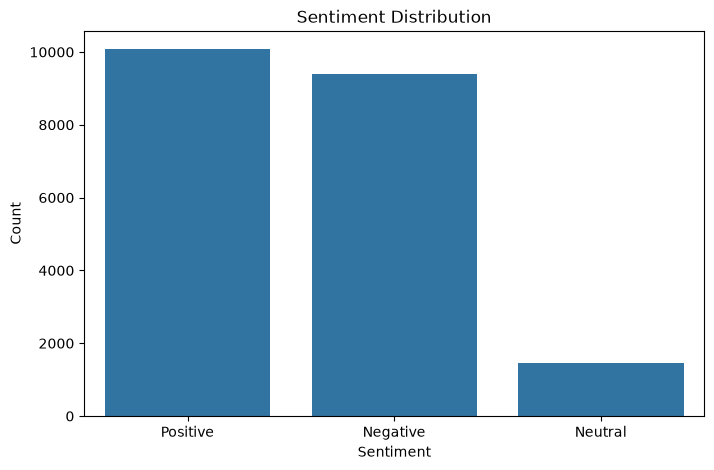

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("sentiment_distribution.png")

plt.show()

In [30]:
pd.crosstab(
    df["Rating_Num"],
    df["Sentiment"]
)

Sentiment,Negative,Neutral,Positive
Rating_Num,,,
1,8144,622,4354
2,612,88,527
3,290,108,476
4,135,161,982
5,227,488,3732


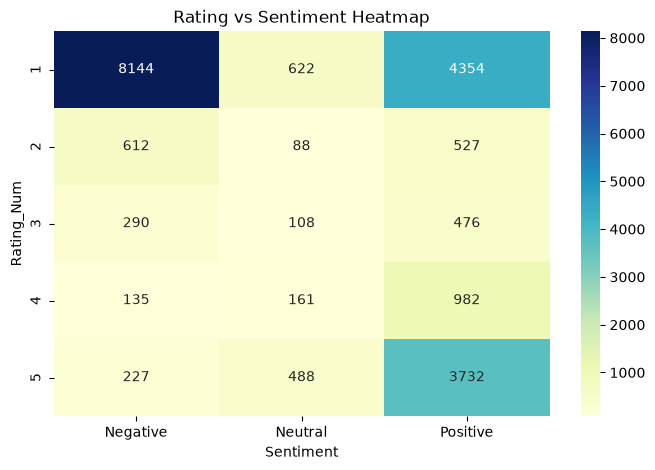

In [31]:
cross_tab = pd.crosstab(
    df["Rating_Num"],
    df["Sentiment"]
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Rating vs Sentiment Heatmap")

plt.savefig("heatmap.png")

plt.show()

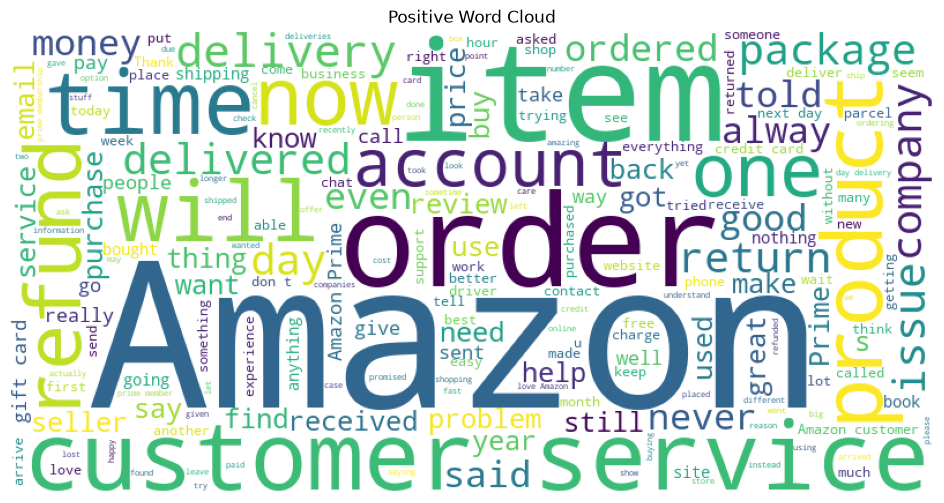

In [32]:
positive_text = " ".join(
    df[df["Sentiment"]=="Positive"]["Review Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Word Cloud")

plt.savefig("positive_wordcloud.png")

plt.show()

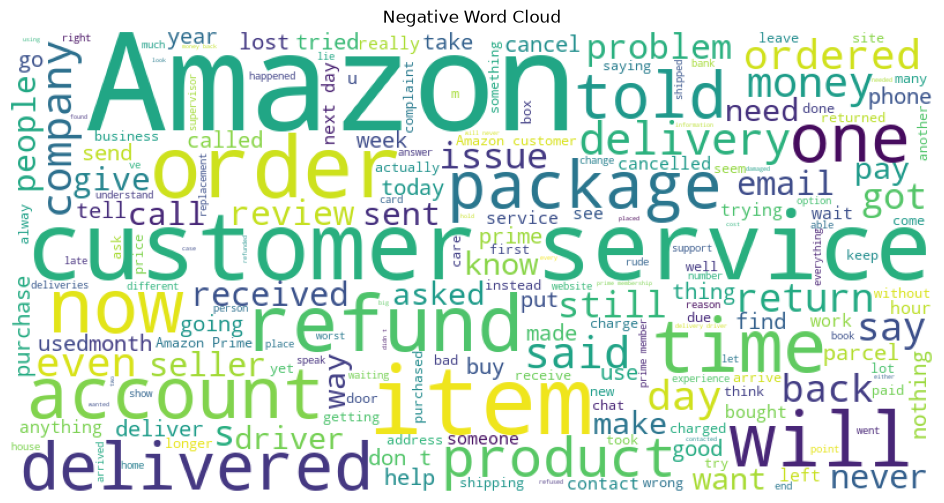

In [33]:
negative_text = " ".join(
    df[df["Sentiment"]=="Negative"]["Review Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Word Cloud")

plt.savefig("negative_wordcloud.png")

plt.show()

In [34]:
df.to_csv(
    "Amazon_Reviews_Final.csv",
    index=False
)

In [35]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Rating_Num,Review_Length,Sentiment
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024",1,590,Positive
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024",1,293,Negative
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024",1,611,Negative
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024",1,450,Negative
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024",1,538,Negative
